Taller 04: Descubriendo Patrones Musicales con Spotify - Anggie Dayanna García Orrego

**Descripción del Caso**

Imagina que trabajas como Data Scientist en una plataforma de streaming musical emergente. El equipo de producto quiere mejorar el sistema de recomendación, pero no tienen etiquetas claras para ciertos tipos de canciones.

Te entregan este conjunto de datos sobre 999 canciones y sus caracteristicas https://www.kaggle.com/datasets/glowstudygram/spotify-songs-and-artists-dataset

El objetivo de la actividad es usar algoritmos de agrupamiento (Clustering) para agrupar las canciones más populares del 2023 basándote únicamente en sus características de audio, ignorando el género o el artista. Luego, deberás interpretar qué representa cada grupo.

In [ ]:
# Bloque 1: Configuración y carga de datos
# Importamos las librerias
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [ ]:
# Cargamos el dataset
df = pd.read_csv(r"c:\Users\lenovo\Desktop\BOOTCAMP DATA SCIENCE\Actividad Entregable 4\spotifydataset.csv")

In [ ]:
# Revisamos las primera lineas de la base completa
df.head()

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [ ]:
# Bloque 2: Limpieza y preparación
# Verificamos número de filas, columnas y si hay vacíos
print(df.shape)

df.info()

(1000, 23)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   str    
 2   genres             837 non-null    str    
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   str    
 6   track_name         1000 non-null   str    
 7   album_name         1000 non-null   str    
 8   release_date       1000 non-null   str    
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudness           1000 non-null   float64
 16  mode               1000 n

In [9]:
# Variables que vamos a usar
X = df[
[
'track_popularity',
'danceability',
'energy',
'key',
'loudness',
'mode',
'speechiness',
'acousticness',
'instrumentalness',
'liveness',
'valence',
'tempo'
]
]

In [ ]:
# Revisamos las primera lineas de las columnas que vamos a usar
print(X.head())

   track_popularity  danceability  energy  key  loudness  mode  speechiness  \
0                89         0.645   0.646    5    -8.334     1       0.0427   
1                85         0.795   0.630    7    -5.854     0       0.0434   
2                83         0.506   0.362   10    -9.480     1       0.0416   
3                80         0.650   0.825    0    -4.645     1       0.0325   
4                79         0.787   0.775    1    -6.614     1       0.0548   

   acousticness  instrumentalness  liveness  valence    tempo  
0        0.0615          0.000030    0.0740    0.295  115.842  
1        0.1570          0.000000    0.0732    0.447   97.998  
2        0.6700          0.000000    0.1760    0.385   84.726  
3        0.0215          0.000024    0.0936    0.593  118.091  
4        0.1900          0.000065    0.1130    0.787  118.998  


In [12]:
# Escalamos los datos ya que por ejemplo danceability tiene números muy pequeños y tempo tiene números muy grandes para acortar esa distancia
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Bloque 3: Reducción de Dimensionalidad (PCA)
# Reducimos las 12 variables a 2 componentes para poder visualizarlas
pca = PCA(2)

X_pca = pca.fit_transform(X_scaled)

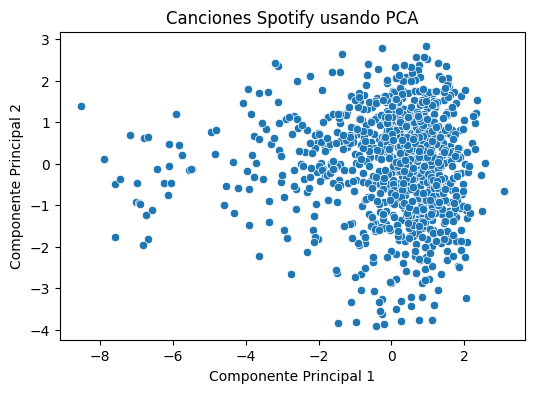

In [ ]:
# Visualización PCA
# Cada punto es una canción, los que estan muy juntos son canciones con características muy similares, los mas alejados son camcniones con
# algun componente atípico diferente al resto.
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1]
)

plt.title("Canciones Spotify usando PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

In [ ]:
# Bloque 4: Modelado con K-Means
# Probamos de 1 a 10 clusters (range 1-11) para comparar la inercia (error), donde 1 es el peor escenario (todo mezclado) 
# y más de 10 no es útil para playlists, para graficar luego el método del codo.
valores_inercia = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(X_pca)

    valores_inercia.append(km.inertia_)

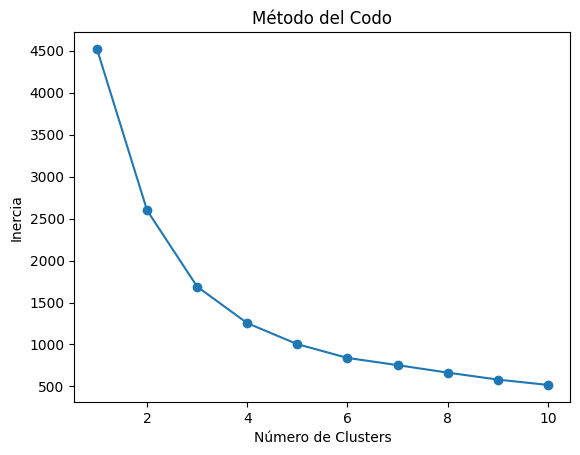

In [17]:
# Graficamos con el médtodo del codo
plt.plot(
    range(1,11),
    valores_inercia,
    marker='o'
)

plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")

plt.show()

In [18]:
# Mediante el método del codo se evaluaron diferentes cantidades de clusters. Se observó que la disminución de la inercia es significativa 
# hasta K=4, mientras que a partir de este punto la mejora es menor. Por esta razón se seleccionaron 4 clusters para el modelo K-Means, por tanto:
# Definimos el modelo final con 4 clusters:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

In [19]:
# Entrenamos el modelo y asignamos a cada canción su grupo (0, 1, 2 o 3)
clusters = kmeans.fit_predict(X_pca)

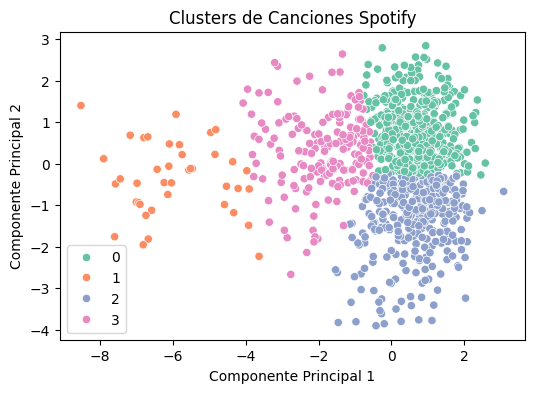

In [20]:
# Bloque 5: Visualización y Análisis
# Usamos un gráfico de dispersión (puntos) porque es la única manera de ver la posición de cada canción en el espacio. Al pasarle la variable 
# hue=clusters, convertimos esa nube azul que teníamos antes en 4 grupos de colores bien diferenciados, me queda en Eje X: Primer Componente Principal 
# (mayor variación), y Eje Y: Segundo Componente Principal (segunda mayor variación)
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=X_pca[:,0],    
    y=X_pca[:,1],    
    hue=clusters,    
    palette='Set2'
)

plt.title("Clusters de Canciones Spotify")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

In [ ]:
# Agregamos la columna 'Cluster' a la tabla original para saber a qué grupo pertenece cada canción
X["Cluster"] = clusters

In [ ]:
# Agrupamos las canciones por su número de cluster y calculamos el promedio de cada característica
# Esto nos dice qué tan bailable, acústico, o enérgico es cada uno de los 4 grupos en promedio
resumen = X.groupby("Cluster").mean()

resumen

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,67.630342,0.722592,0.687308,5.532051,-6.030331,0.500000,0.103863,0.217717,0.002019,0.157657,0.634200,115.033096
1,41.825000,0.332275,0.177428,4.125000,-21.904550,0.675000,0.047205,0.924450,0.794752,0.120480,0.252897,112.828250
2,55.052960,0.516530,0.805794,4.816199,-5.177461,0.732087,0.087702,0.091368,0.062932,0.270007,0.438248,137.721639
3,49.315789,0.550643,0.427749,5.514620,-10.526497,0.684211,0.074578,0.571001,0.127273,0.137633,0.403754,114.539082


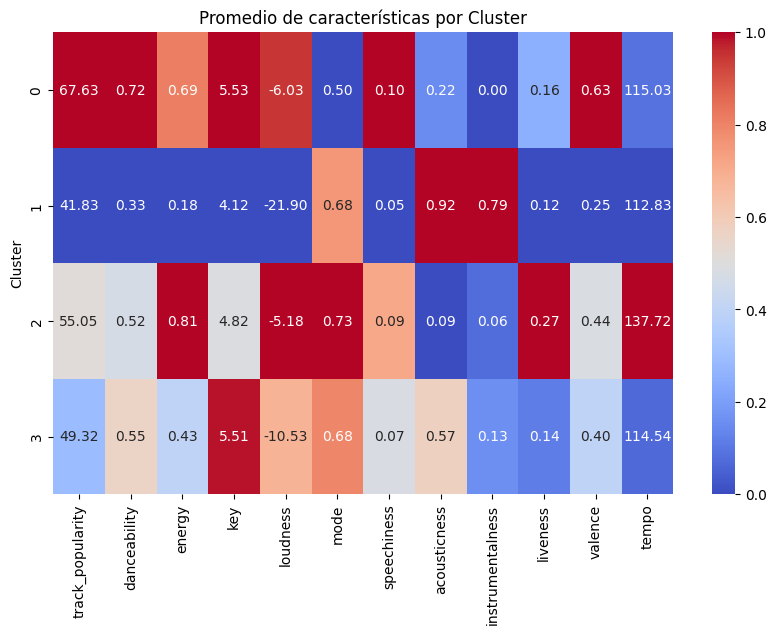

In [ ]:
# Visualización con un Mapa de Calor
# Aplicamos un escalado Min-Max por columna para corregir las diferencias de escalas (como tempo o popularity) y los valores negativos de 
# loudness, permitiendo que el mapa pinte los colores correctamente (Rojo=Máximo, Azul=Mínimo) manteniendo los valores reales
# en las etiquetas del gráfico.
X["Cluster"] = clusters
resumen = X.groupby("Cluster").mean()

resumen_escalado = (resumen - resumen.min()) / (resumen.max() - resumen.min())

plt.figure(figsize=(10, 6))

sns.heatmap(
    resumen_escalado,  
    annot=resumen,     
    cmap="coolwarm",   
    fmt=".2f"          
)

plt.title("Promedio de características por Cluster")
plt.show()

**CONCLUSIONES**

1. Preparación y estandarización de los datos

La selección exclusiva de las variables track_popularity, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence y tempo permitió enfocar el análisis únicamente en las características auditivas de las canciones. Posteriormente, la estandarización mediante StandardScaler fue necesaria debido a que variables como tempo y loudness manejan escalas muy diferentes a variables como danceability o acousticness, evitando que algunas características tuvieran mayor influencia que otras durante el proceso de agrupamiento.

2. Reducción de dimensionalidad y clustering

La aplicación de PCA permitió reducir las 12 variables originales a dos componentes principales, facilitando la representación visual de los datos y conservando la información más relevante para el análisis. Mediante el método del codo se determinó que K = 4 era una cantidad adecuada de clusters, ya que a partir de este valor la reducción de la inercia dejó de ser significativa. Esto permitió generar una segmentación de las canciones basada únicamente en similitudes de sus características de audio.

3. Interpretación de los clusters mediante visualizaciones

Las visualizaciones obtenidas evidenciaron la existencia de perfiles musicales diferenciados. El análisis de los promedios por cluster y del mapa de calor mostró que el Cluster 0 concentró los mayores valores de track_popularity, danceability y valence, mientras que el Cluster 1 presentó los valores más altos de acousticness e instrumentalness. Por su parte, el Cluster 2 se caracterizó por registrar los mayores niveles de energy, tempo y liveness. Estos resultados demuestran que el algoritmo logró identificar grupos de canciones con comportamientos auditivos claramente distintos sin utilizar información de artistas o géneros musicales.

4. Relación entre características de audio y popularidad

la información del mapa de calor realizado sugiere que las canciones con mayores valores de danceability, energy y valence tienden a presentar también valores más altos de track_popularity, como se observó en el Cluster 0. Por el contrario, los grupos con valores elevados de acousticness e instrumentalness registraron niveles de popularidad más bajos. Esto indica que, dentro de este conjunto de datos, las canciones más dinámicas, bailables y emocionalmente positivas tienen una mayor aceptación entre los oyentes que las canciones predominantemente acústicas o instrumentales.

El análisis mostró una relación entre energy y loudness. Los clusters con mayores valores de energía, como el Cluster 2, presentaron valores de loudness más cercanos a cero (-5.18 dB), indicando canciones más fuertes e intensas. En contraste, el Cluster 1 registró el menor nivel de energía y el valor más bajo de loudness (-21.90 dB), lo que sugiere canciones más suaves y acústicas.